## FIRST Decision Tree Classification

### 1. Загружаем необходимые библиотеки и генерируем датасет

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

#### 1.1. Поверхностно изучаем загруженные данные

In [3]:
iris.DESCR

'.. _iris_dataset:\n\nIris plants dataset\n--------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 150 (50 in each of three classes)\n:Number of Attributes: 4 numeric, predictive attributes and the class\n:Attribute Information:\n    - sepal length in cm\n    - sepal width in cm\n    - petal length in cm\n    - petal width in cm\n    - class:\n            - Iris-Setosa\n            - Iris-Versicolour\n            - Iris-Virginica\n\n:Summary Statistics:\n\n============== ==== ==== ======= ===== ====================\n                Min  Max   Mean    SD   Class Correlation\n============== ==== ==== ======= ===== ====================\nsepal length:   4.3  7.9   5.84   0.83    0.7826\nsepal width:    2.0  4.4   3.05   0.43   -0.4194\npetal length:   1.0  6.9   3.76   1.76    0.9490  (high!)\npetal width:    0.1  2.5   1.20   0.76    0.9565  (high!)\n============== ==== ==== ======= ===== ====================\n\n:Missing Attribute Values: None\n:Class Distribution: 

In [4]:
df = pd.DataFrame(X, columns = iris.feature_names)
df["target"] = y
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


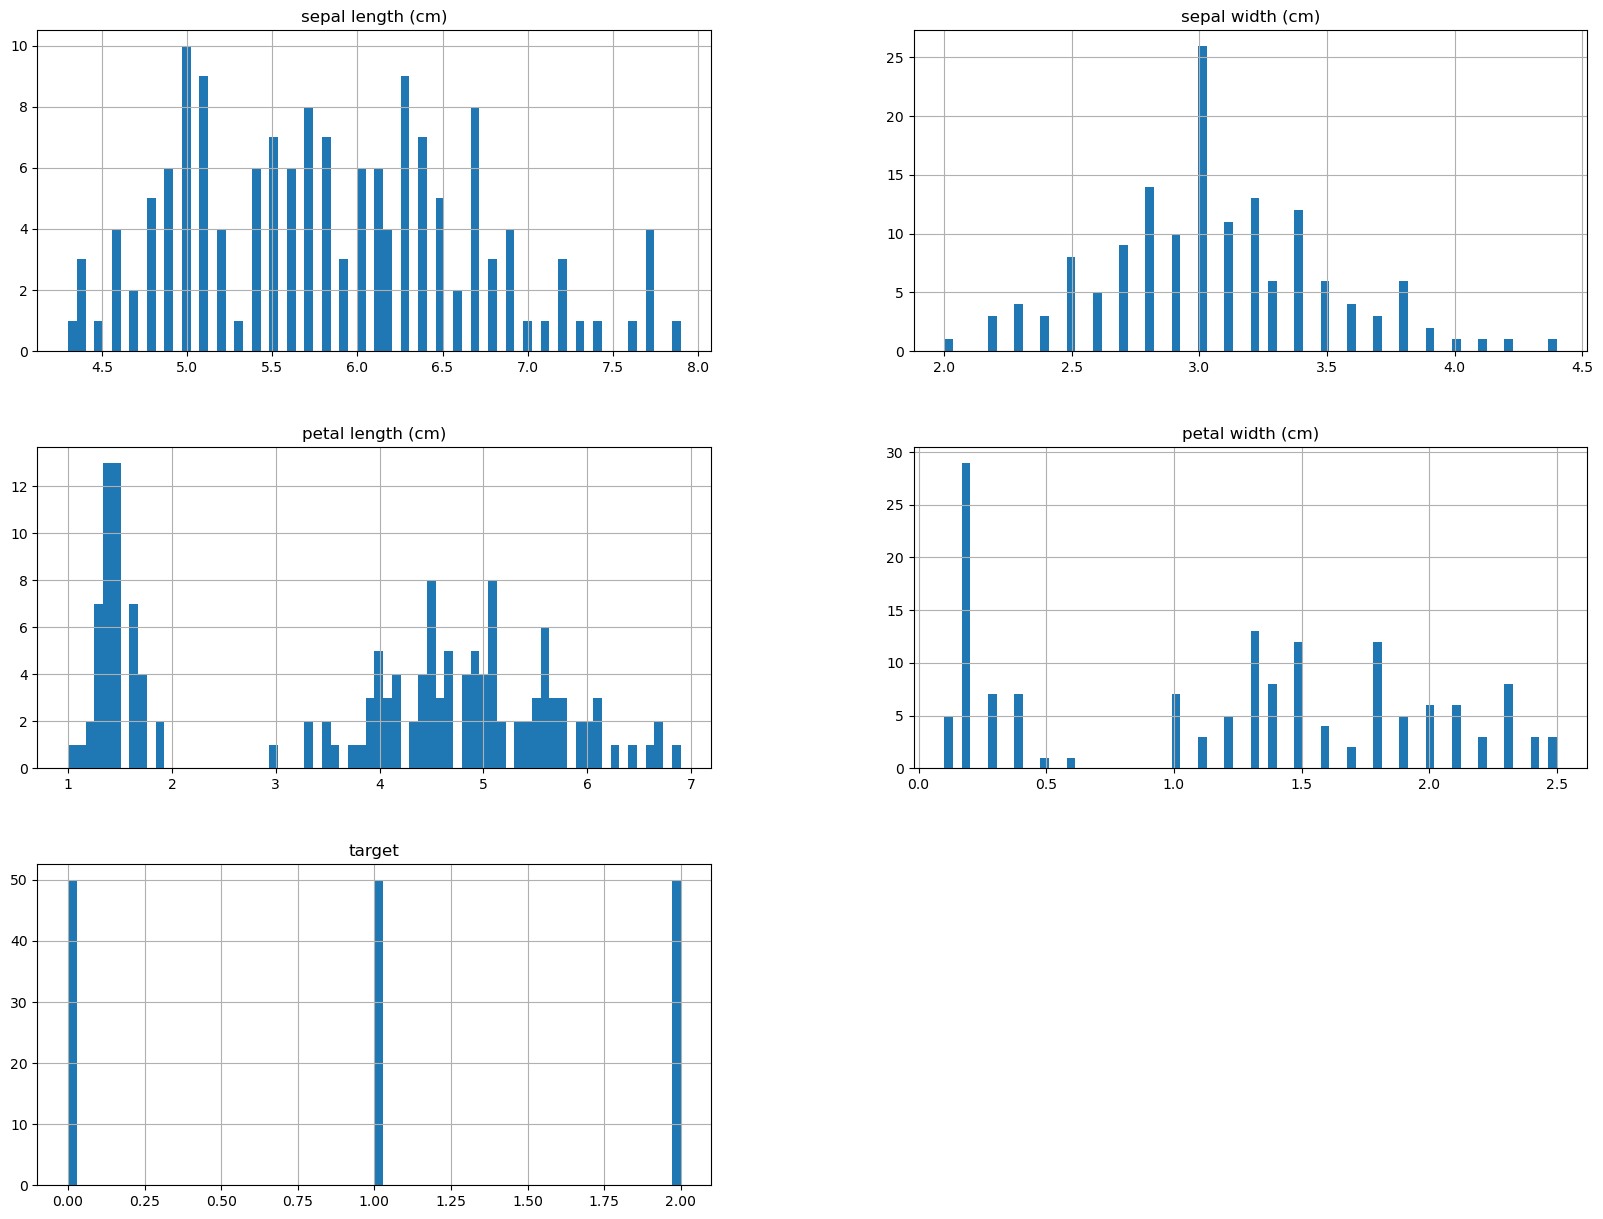

In [6]:
df.hist(bins = 70, figsize = (20,15))
plt.show()

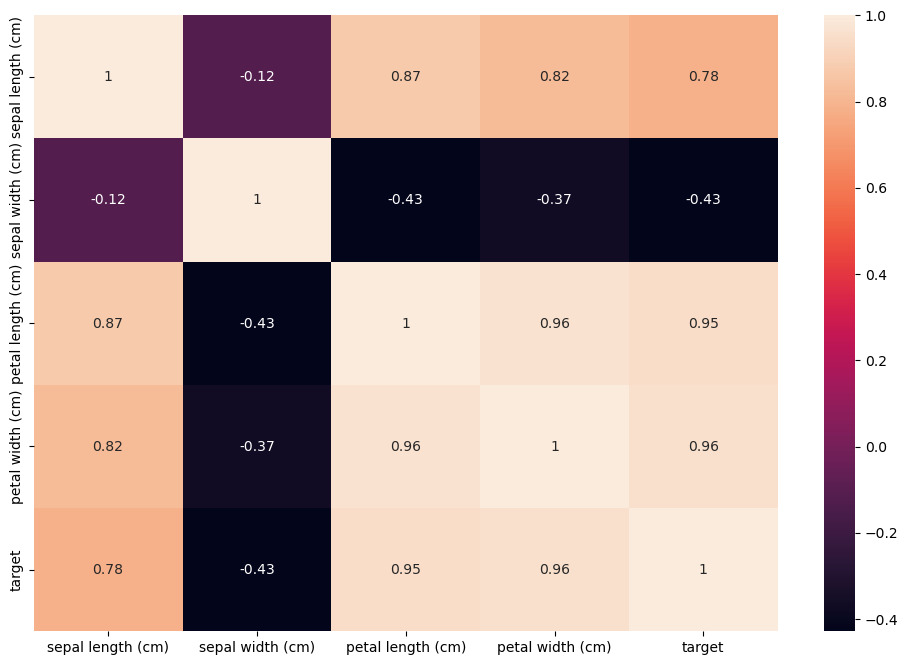

In [7]:
plt.figure(figsize = (12, 8))
sns.heatmap(df.corr(), annot=True)
plt.show()

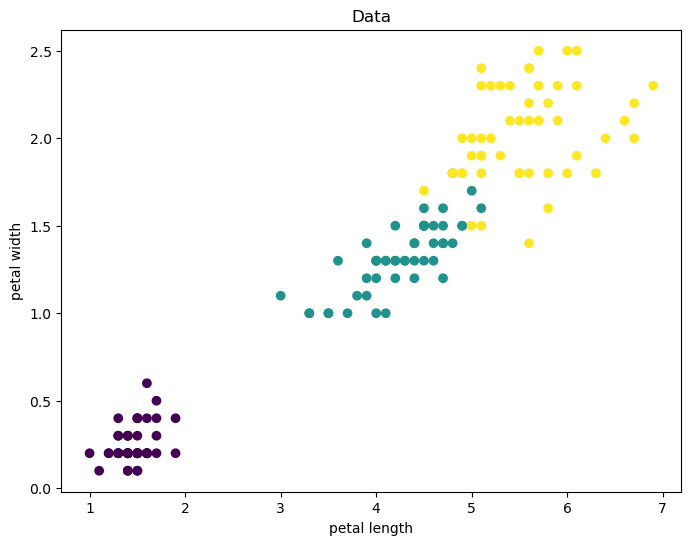

In [8]:
plt.figure(figsize = (8, 6))
plt.scatter(X[:,2], X[:,3], c = y)
plt.title("Data")
plt.xlabel("petal length")
plt.ylabel("petal width")
plt.show()

#### 1.2. Создаем тренировочные и тестовые выборки

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((112, 4), (38, 4), (112,), (38,))

### 2. Создаём собственный класс **DecisionTree** для задачи классификации

In [10]:
class DecisionTree:
    def __init__(model):
        pass

    def split_dataset(model, X, y, feature_index, threshold):
        split = {
            "X_right": X[np.where(X[:, feature_index] >= threshold)],
            "y_right": y[np.where(X[:, feature_index] >= threshold)],
            "X_left": X[np.where(X[:, feature_index] < threshold)],
            "y_left": y[np.where(X[:, feature_index] < threshold)]
        }
        return split

    def cost_with_gini(model, y_left, y_right):
        total = len(y_left) + len(y_right)
        gini_left = gini_right = 1
        
        if len(y_left) != 0:
            for s in range(model.count_classes):
                gini_left = gini_left - (len(np.where(y_left == s)[0]) / len(y_left)) ** 2

        if len(y_right) != 0:
            for s in range(model.count_classes):
                gini_right = gini_right - (len(np.where(y_right == s)[0]) / len(y_right)) ** 2
            
        return (len(y_left) / total) * gini_left + (len(y_right) / total) * gini_right

    def find_best_split(model, X, y):
        best_index = 0
        best_threshold = X[0][0]
        best_cost = model.cost_with_gini(model.split_dataset(X, y, 0, best_threshold)["y_left"], model.split_dataset(X, y, 0, best_threshold)["y_right"])
        #best_index, best_threshold, best_cost = np.inf, np.inf, np.inf
        
        for i in range(X.shape[1]):
            for j in range(X.shape[0]):
                current_cost = model.cost_with_gini(model.split_dataset(X, y, i, X[j][i])["y_left"], model.split_dataset(X, y, i, X[j][i])["y_right"])
                
                if current_cost < best_cost:
                    best_cost = current_cost
                    best_index = i
                    best_threshold = X[j][i]

        best_split = dict(
            model.split_dataset(X, y, best_index, best_threshold),
            threshold = best_threshold,
            cost = best_cost,
            feature_index = best_index
        )
        return best_split

    def build_tree(model, node_dict, current_depth, max_depth, min_samples):
        if len(node_dict["y_right"]) == 0 or len(node_dict["y_left"]) == 0:
            node_dict["right_child"] = node_dict["left_child"] = model.create_node(np.append(node_dict["y_right"], node_dict["y_left"]))
            return node_dict
            
        if current_depth >= max_depth:
            node_dict["right_child"] = model.create_node(node_dict["y_right"])
            node_dict["left_child"] = model.create_node(node_dict["y_left"])
            return None

        if node_dict["X_right"].shape[0] <= min_samples:
            node_dict["right_child"] = model.create_node(node_dict["y_right"])
        else:
            node_dict["right_child"] = model.find_best_split(node_dict["X_right"], node_dict["y_right"])
            model.build_tree(node_dict["right_child"], current_depth + 1, max_depth, min_samples)

        if node_dict["X_left"].shape[0] <= min_samples:
            node_dict["left_child"] = model.create_node(node_dict["y_left"])
        else:
            node_dict["left_child"] = model.find_best_split(node_dict["X_left"], node_dict["y_left"])
            model.build_tree(node_dict["left_child"], current_depth + 1, max_depth, min_samples)

        return node_dict

    def create_node(model, y):
        return max(set(y), key = list(y).count)

    def train(model, X, y, max_depth, min_samples):
        model.count_classes = len(set(y))
        model.tree = model.build_tree(model.find_best_split(X, y), 1, max_depth, min_samples)

    def predict(model, X, node):
        if X[node["feature_index"]] >= node["threshold"]:
            if isinstance(node["right_child"], (int, np.integer)):
                return node["right_child"]
            else:
                return model.predict(X, node["right_child"])
        else:
            if isinstance(node["left_child"], (int, np.integer)):
                return node["left_child"]
            else:
                return model.predict(X, node["left_child"])

    def print_tree(model, node, depth = 0):
        if isinstance(node, (int, np.integer)):
            print(f"{depth * '   '} predicted class: {round(node, 4)}")
        else:
            print(f"{depth * '   '} feature {node['feature_index']} - {round(node['threshold'], 4)}, "
             f"cost of split: {round(node['cost'], 4)}")
            model.print_tree(node["right_child"], depth + 1)
            model.print_tree(node["left_child"], depth + 1)

#### 2.1. Обучаем модель с глубиной дерева **max_depth = 2**

In [11]:
model_1 = DecisionTree()
model_1.train(X_train, y_train, 2, 4)

#### 2.1.1. Схема соответсвующего дерева 

In [12]:
model_1.print_tree(model_1.tree)

 feature 2 - 3.0, cost of split: 0.3393
    feature 3 - 1.8, cost of split: 0.0755
       predicted class: 2
       predicted class: 1
    feature 0 - 5.0, cost of split: 0.0
       predicted class: 0
       predicted class: 0


#### 2.1.2. **Точность предсказания** данного дерева

In [13]:
count_1 = 0
for i in range(X_test.shape[0]):
    if y_test[i] != model_1.predict(X_test[i], model_1.tree):
        count_1 += 1

print(f"Accuracy on test data: {((len(y_test) - count_1) / len(y_test)) * 100} %")

Accuracy on test data: 92.10526315789474 %


#### 2.2. Обучаем модель с глубиной дерева **max_depth = 3**

In [14]:
model_2 = DecisionTree()
model_2.train(X_train, y_train, 3, 4)

#### 2.2.1. Схема соответсвующего дерева 

In [15]:
model_2.print_tree(model_2.tree)

 feature 2 - 3.0, cost of split: 0.3393
    feature 3 - 1.8, cost of split: 0.0755
       feature 2 - 4.9, cost of split: 0.027
          predicted class: 2
          predicted class: 1
       feature 2 - 5.0, cost of split: 0.0342
          predicted class: 2
          predicted class: 1
    feature 0 - 5.0, cost of split: 0.0
       feature 0 - 5.0, cost of split: 0.0
          predicted class: 0
          predicted class: 0
       feature 0 - 4.8, cost of split: 0.0
          predicted class: 0
          predicted class: 0


#### 2.2.2. **Точность предсказания** данного дерева

In [16]:
count_2 = 0
for i in range(X_test.shape[0]):
    if y_test[i] != model_2.predict(X_test[i], model_2.tree):
        count_2 += 1

print(f"Accuracy on test data: {((len(y_test) - count_2) / len(y_test)) * 100} %")

Accuracy on test data: 92.10526315789474 %


### 3. Обучение деревьев решений с помощью библиотеки **scikit-learn**

In [17]:
from sklearn.tree import DecisionTreeClassifier

clas_1 = DecisionTreeClassifier(criterion='gini', max_depth = 2)
clas_2 = DecisionTreeClassifier(criterion='gini', max_depth = 3)
clas_1.fit(X_train, y_train)
clas_2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### 3.1. **Точность предсказания** дерева с **max_depth = 2**

In [18]:
count_1 = 0
for i in range(X_test.shape[0]):
    if y_test[i] != clas_1.predict(X_test)[i]:
        count_1 += 1

print(f"Accuracy on test data: {((len(y_test) - count_1) / len(y_test)) * 100} %")

Accuracy on test data: 92.10526315789474 %


#### 3.2. **Точность предсказания** дерева с **max_depth = 3**

In [19]:
count_2 = 0
for i in range(X_test.shape[0]):
    if y_test[i] != clas_2.predict(X_test)[i]:
        count_2 += 1

print(f"Accuracy on test data: {((len(y_test) - count_2) / len(y_test)) * 100} %")

Accuracy on test data: 92.10526315789474 %


## Выводы:
* Модель, построенная и обученная собственным классом **DecisionTree**, на тестовой выборке ведёт себя и предсказывает метку класса абсолютно также (*Accuracy on test data:* 92.10526315789474 % - достаточно солидный результат для случая **max_depth = 2**), как и модель библиотеки **scikit-learn**, что может говорить исключительно о достижении поставленной цели - собственно ручного построения дерева решений для задачи классификации
* Признаки (характеристики растения Iris), участвующие в итоговом разбиении набора данных в дереве решений, есть те же самые признаки, что больше всего коррелируют со значением метки класса (см. матрицу корреляций в п. 1.1), а именно признак с индексом 2 - "petal length" (корреляционное значение с target - 0.95), с индексом 3 - "petal width" (корреляционное значение с target - 0.96) и с индексом 0 - "sepal length" (корреляционное значение с target - 0.78). Тут же замечаем, что признак с индексом 1 - "sepal width" (корреляционное значение с target -0.43 наименьшее из всех) вовсе не участвует в дереве решений что является непосредственным следствием корреляционной матрицы для данного датасета
* Мы видим, что точность предсказания дерева с **max_depth = 2** и точность предсказания дерева с **max_depth = 3** абсолютно идентичны, то есть увеличении глубины дерева на единицу (или добавления ещё 4 новых развилок и соответсвенно листов) совсем не добавляет точности к предсказанию метки класса (но и на удивление модель с большей глубиной не переобучилась, несмотря на совсем маленький размер датасета). Данное явление может быть следствием совсем небольшого количества наших данных (+ учитываем что размер тренировочной выборки = 0,75 * размер общей выборки), что дополнительная глубина оказалось излишней